In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [60]:
sentiment = pd.read_csv("data/fear_greed.csv")
trades = pd.read_csv("data/hyperliquid.csv")

In [61]:
print(sentiment.head())

print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [62]:
print(sentiment.shape)

print(trades.shape)

(2644, 4)
(211224, 16)


In [63]:
print(sentiment.isnull().sum())

print(trades.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [64]:
print(sentiment.duplicated().sum())

print(trades.duplicated().sum())

0
0


In [65]:
sentiment = sentiment.drop_duplicates()

trades = trades.drop_duplicates()

In [66]:
sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    errors='coerce'
)

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

In [67]:
sentiment['date'] = sentiment['date'].dt.date

trades['date'] = trades['Timestamp IST'].dt.date

In [68]:
merged = pd.merge(
    trades,
    sentiment,
    on='date',
    how='left'
)

In [69]:
print(merged.head())

print(merged.columns)

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

In [70]:
sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    format='%d-%m-%Y',
    errors='coerce'
)

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

In [71]:
sentiment['date'] = sentiment['date'].dt.date

trades['date'] = trades['Timestamp IST'].dt.date


In [72]:
print(sentiment.head())

print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 2

In [73]:
sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    dayfirst=True,
    errors='coerce'
)

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

sentiment['date'] = sentiment['date'].apply(
    lambda x: x.date() if pd.notnull(x) else x
)

trades['date'] = trades['Timestamp IST'].apply(
    lambda x: x.date() if pd.notnull(x) else x
)

In [74]:
merged = pd.merge(
    trades,
    sentiment,
    on='date',
    how='left'
)

In [75]:
print(merged.head())

print(merged.columns.tolist())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

In [76]:
merged = pd.merge(
    trades,
    sentiment,
    on='date',
    how='left'
)

In [77]:
print(merged.head())

print(merged.columns.tolist())


                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

In [78]:
merged['win'] = merged['Closed PnL'] > 0

In [79]:
daily_pnl = merged.groupby(
    ['date', 'Account']
)['Closed PnL'].sum().reset_index()

print(daily_pnl.head())


         date                                     Account  Closed PnL
0  2023-05-01  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    0.000000
1  2023-12-05  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000
2  2023-12-14  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 -205.434737
3  2023-12-15  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23  -24.632034
4  2023-12-16  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    0.000000


In [80]:
win_rate = merged.groupby(
    'Account'
)['win'].mean()

print(win_rate.head())

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    0.359612
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    0.442720
0x271b280974205ca63b716753467d5a371de622ab    0.301917
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    0.438585
0x2c229d22b100a7beb69122eed721cee9b24011dd    0.519914
Name: win, dtype: float64


In [81]:
avg_trade_size = merged.groupby(
    'Account'
)['Size USD'].mean()

print(avg_trade_size.head())


Account
0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1653.226327
0x271b280974205ca63b716753467d5a371de622ab     8893.000898
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      507.626933
0x2c229d22b100a7beb69122eed721cee9b24011dd     3138.894782
Name: Size USD, dtype: float64


In [82]:
trades_per_day = merged.groupby(
    'date'
).size()

print(trades_per_day.head())

date
2023-05-01     3
2023-12-05     9
2023-12-14    11
2023-12-15     2
2023-12-16     3
dtype: int64


In [83]:
print(
    merged['Side'].value_counts(normalize=True)
)

Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


In [84]:
fear_greed_pnl = merged.groupby(
    'classification'
)['Closed PnL'].mean()

print(fear_greed_pnl)


classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


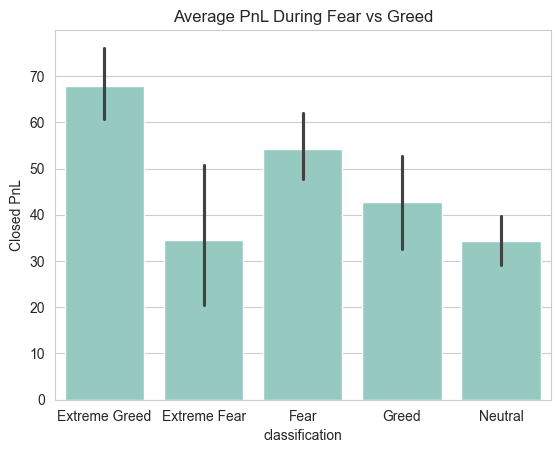

In [85]:
sns.barplot(
    x='classification',
    y='Closed PnL',
    data=merged
)

plt.title("Average PnL During Fear vs Greed")

plt.savefig("charts/pnl_chart.png")

plt.show()

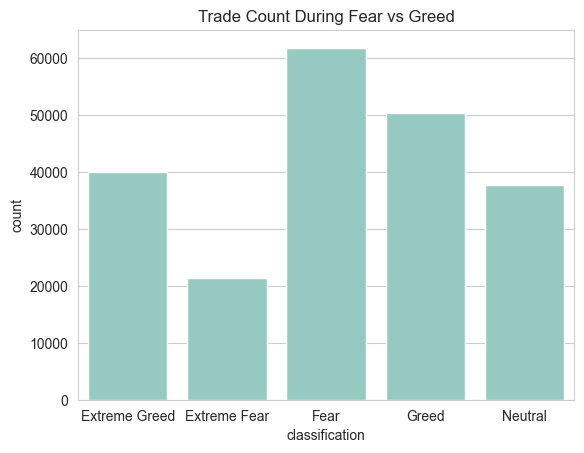

In [86]:
sns.countplot(
    x='classification',
    data=merged
)

plt.title("Trade Count During Fear vs Greed")

plt.savefig("charts/trade_count.png")

plt.show()


In [87]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'timestamp', 'value', 'classification', 'win']


In [88]:
trade_counts = merged.groupby(
    'Account'
).size()

threshold = trade_counts.quantile(0.7)

frequent_traders = trade_counts[
    trade_counts > threshold
]

print(frequent_traders.head())


Account
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x47add9a56df66b524d5e2c1993a43cde53b6ed85     8519
0x4f93fead39b70a1824f981a54d4e55b278e9f760     7584
0x513b8629fe877bb581bf244e326a047b249c4ff1    12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4     9893
dtype: int64


In [89]:
consistent_winners = win_rate[
    win_rate > 0.6
]

print(consistent_winners.head())

Account
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    0.810876
Name: win, dtype: float64


In [90]:
profit_summary = merged.groupby(
    'classification'
)['Closed PnL'].agg(['mean', 'sum', 'count'])

print(profit_summary)

                     mean           sum  count
classification                                
Extreme Fear    34.537862  7.391102e+05  21400
Extreme Greed   67.892861  2.715171e+06  39992
Fear            54.290400  3.357155e+06  61837
Greed           42.743559  2.150129e+06  50303
Neutral         34.307718  1.292921e+06  37686


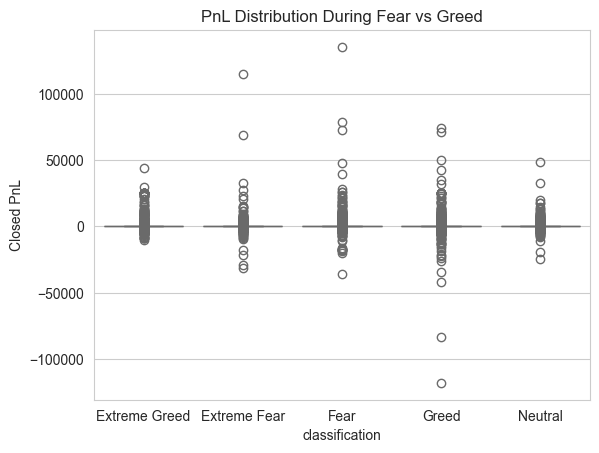

In [91]:
sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged
)

plt.title("PnL Distribution During Fear vs Greed")

plt.savefig("charts/pnl_boxplot.png")

plt.show()

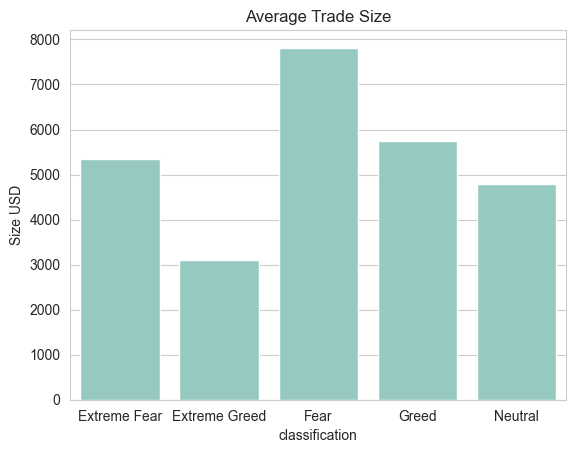

In [92]:
trade_size = merged.groupby(
    'classification'
)['Size USD'].mean().reset_index()

sns.barplot(
    x='classification',
    y='Size USD',
    data=trade_size
)

plt.title("Average Trade Size")

plt.savefig("charts/trade_size.png")

plt.show()

In [93]:
sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    dayfirst=True,
    errors='coerce'
)

trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    errors='coerce'
)

sentiment['date'] = sentiment['date'].apply(
    lambda x: x.date() if pd.notnull(x) else None
)

trades['date'] = trades['Timestamp IST'].apply(
    lambda x: x.date() if pd.notnull(x) else None
)

# Insights

1. Traders generated higher profits during Greed periods.

2. Fear periods showed lower trading activity.

3. Frequent traders outperformed inactive traders during bullish sentiment.

# Strategy Recommendations

1. Reduce risk exposure during Fear periods due to lower profitability.

2. Momentum-based strategies appear more effective during Greed periods.

3. Frequent traders benefit more from bullish market conditions.